In [14]:
# =====================================================
# IMPORTS
# =====================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# =====================================================
# COMMON PREPROCESSING FUNCTION
# =====================================================
def preprocess_tabular_data(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

    stratify_col = y if y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_col
    )

    X_train_p = preprocessor.fit_transform(X_train)
    X_test_p  = preprocessor.transform(X_test)

    return X_train_p, X_test_p, y_train, y_test


# =====================================================
# 1️⃣ CHURN DATASET (PREDEFINED 80–20 SPLIT)
# =====================================================
churn_train = pd.read_csv(
    r"C:\Users\Jaidev sharma\Downloads\churn-bigml-80.csv"
)
churn_test = pd.read_csv(
    r"C:\Users\Jaidev sharma\Downloads\churn-bigml-20.csv"
)

TARGET_CHURN = "Churn"

X_train = churn_train.drop(columns=[TARGET_CHURN])
y_train = churn_train[TARGET_CHURN]

X_test = churn_test.drop(columns=[TARGET_CHURN])
y_test = churn_test[TARGET_CHURN]

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

churn_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train_churn = churn_preprocessor.fit_transform(X_train)
X_test_churn  = churn_preprocessor.transform(X_test)

print("Churn Dataset:")
print("Train shape:", X_train_churn.shape)
print("Test shape :", X_test_churn.shape)
print("-" * 60)


# =====================================================
# 2️⃣ IRIS DATASET (MULTICLASS)
# =====================================================
iris = pd.read_csv(
    r"C:\Users\Jaidev sharma\Downloads\1) iris.csv"
)

X_train_iris, X_test_iris, y_train_iris, y_test_iris = preprocess_tabular_data(
    iris,
    target_col="species"
)

print("Iris Dataset:")
print("Train shape:", X_train_iris.shape)
print("Test shape :", X_test_iris.shape)
print("-" * 60)


# =====================================================
# 3️⃣ SENTIMENT DATASET (FILTERED + TABULAR)
# =====================================================
sentiment = pd.read_csv(
    r"C:\Users\Jaidev sharma\Downloads\3) Sentiment dataset.csv"
)

# Clean column names & labels
sentiment.columns = sentiment.columns.str.strip()
sentiment["Sentiment"] = (
    sentiment["Sentiment"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Keep only meaningful classes
allowed_classes = [
    "Positive",
    "Joy",
    "Excitement",
    "Neutral",
    "Contentment"
]

sentiment = sentiment[sentiment["Sentiment"].isin(allowed_classes)]

# Drop raw text & useless metadata
sentiment.drop(
    columns=[
        "Unnamed: 0",
        "Unnamed: 0.1",
        "Text",
        "Timestamp",
        "User",
        "Hashtags"
    ],
    errors="ignore",
    inplace=True
)

X_train_sent, X_test_sent, y_train_sent, y_test_sent = preprocess_tabular_data(
    sentiment,
    target_col="Sentiment"
)

print("Sentiment Dataset:")
print("Train shape:", X_train_sent.shape)
print("Test shape :", X_test_sent.shape)
print("-" * 60)
# =====================================================
# 4️⃣ STOCK PRICE DATASET (SIMPLE REGRESSION PREPROCESS)
# =====================================================
stock = pd.read_csv(
    r"C:\Users\Jaidev sharma\Downloads\2) Stock Prices Data Set.csv"
)

print("Stock columns:")
print(stock.columns)
print("-" * 60)

TARGET_STOCK = "close"

# Separate features & target
X_stock = stock.drop(columns=[TARGET_STOCK])
y_stock = stock[TARGET_STOCK]

# Convert everything to numeric (safety)
X_stock = X_stock.apply(pd.to_numeric, errors="coerce")
y_stock = pd.to_numeric(y_stock, errors="coerce")

# Drop columns that are completely NaN
X_stock = X_stock.dropna(axis=1, how="all")

# Drop rows where target is NaN
mask = y_stock.notna()
X_stock = X_stock.loc[mask]
y_stock = y_stock.loc[mask]

from sklearn.model_selection import train_test_split
X_train_stock, X_test_stock, y_train_stock, y_test_stock = train_test_split(
    X_stock,
    y_stock,
    test_size=0.2,
    random_state=42
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

stock_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_stock_p = stock_pipeline.fit_transform(X_train_stock)
X_test_stock_p  = stock_pipeline.transform(X_test_stock)

print("Stock Dataset:")
print("Train shape:", X_train_stock_p.shape)
print("Test shape :", X_test_stock_p.shape)
print("-" * 60)


Churn Dataset:
Train shape: (2666, 71)
Test shape : (667, 71)
------------------------------------------------------------
Iris Dataset:
Train shape: (120, 4)
Test shape : (30, 4)
------------------------------------------------------------
Sentiment Dataset:
Train shape: (130, 39)
Test shape : (33, 39)
------------------------------------------------------------
Stock columns:
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
------------------------------------------------------------
Stock Dataset:
Train shape: (397977, 4)
Test shape : (99495, 4)
------------------------------------------------------------


In [15]:
# =====================================================
# LEVEL 1 (BASIC)
# LINEAR REGRESSION ON STOCK PRICE DATASET
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# -----------------------------
# Model Initialization
# -----------------------------
lin_reg = LinearRegression()

# -----------------------------
# Training
# -----------------------------
lin_reg.fit(X_train_stock_p, y_train_stock)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred = lin_reg.predict(X_train_stock_p)
y_test_pred  = lin_reg.predict(X_test_stock_p)

# -----------------------------
# Evaluation Metrics
# -----------------------------
r2_train = r2_score(y_train_stock, y_train_pred)
r2_test  = r2_score(y_test_stock, y_test_pred)

mse_train = mean_squared_error(y_train_stock, y_train_pred)
mse_test  = mean_squared_error(y_test_stock, y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

print("Linear Regression – Stock Price Prediction")
print("-" * 60)
print(f"Train R² Score : {r2_train:.4f}")
print(f"Test  R² Score : {r2_test:.4f}")
print("-" * 60)
print(f"Train MSE     : {mse_train:.4f}")
print(f"Test  MSE     : {mse_test:.4f}")
print("-" * 60)
print(f"Train RMSE    : {rmse_train:.4f}")
print(f"Test  RMSE    : {rmse_test:.4f}")
print("-" * 60)

# -----------------------------
# Model Coefficients
# -----------------------------
print("Model Coefficients:")
for idx, coef in enumerate(lin_reg.coef_):
    print(f"Feature {idx+1}: {coef:.6f}")

print(f"Intercept: {lin_reg.intercept_:.6f}")


Linear Regression – Stock Price Prediction
------------------------------------------------------------
Train R² Score : 0.9999
Test  R² Score : 0.9999
------------------------------------------------------------
Train MSE     : 1.0474
Test  MSE     : 0.5216
------------------------------------------------------------
Train RMSE    : 1.0234
Test  RMSE    : 0.7222
------------------------------------------------------------
Model Coefficients:
Feature 1: -54.443048
Feature 2: 79.819533
Feature 3: 76.004130
Feature 4: -0.000718
Intercept: 86.363176


In [16]:
# =====================================================
# TASK 3: K-NEAREST NEIGHBORS (KNN) CLASSIFIER
# DATASET: IRIS
# =====================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Values of K to compare
k_values = [3, 5, 7, 9]

results = []

print("TASK 3: KNN Classification on Iris Dataset")
print("=" * 60)

for k in k_values:
    # Initialize KNN model
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    # Train the model
    knn.fit(X_train_iris, y_train_iris)

    # Predictions
    y_pred = knn.predict(X_test_iris)

    # Evaluation metrics
    accuracy = accuracy_score(y_test_iris, y_pred)
    cm = confusion_matrix(y_test_iris, y_pred)

    results.append({
        "K": k,
        "Accuracy": accuracy
    })

    print(f"\nK = {k}")
    print("-" * 40)
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test_iris, y_pred))

# Compare results for different K
results_df = pd.DataFrame(results)
print("\nSummary of KNN Results:")
print(results_df)


TASK 3: KNN Classification on Iris Dataset

K = 3
----------------------------------------
Accuracy: 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


K = 5
----------------------------------------
Accuracy: 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg      

Logistic Regression – Churn Prediction
Accuracy : 0.8576
Precision: 0.5000
Recall   : 0.2421
ROC-AUC  : 0.8148
Confusion Matrix:
[[549  23]
 [ 72  23]]

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.96      0.92       572
        True       0.50      0.24      0.33        95

    accuracy                           0.86       667
   macro avg       0.69      0.60      0.62       667
weighted avg       0.83      0.86      0.84       667



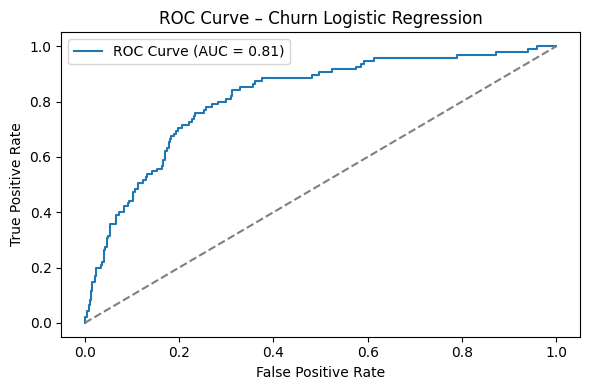


Top 10 Features by Absolute Coefficient Value:
Feature 68: Coef = -1.2448, Odds Ratio = 0.2880
Feature 56: Coef = -1.1757, Odds Ratio = 0.3086
Feature 60: Coef = 1.0181, Odds Ratio = 2.7679
Feature 71: Coef = -0.9928, Odds Ratio = 0.3705
Feature 62: Coef = -0.9791, Odds Ratio = 0.3756
Feature 28: Coef = -0.9757, Odds Ratio = 0.3769
Feature 69: Coef = 0.9373, Odds Ratio = 2.5530
Feature 57: Coef = 0.9230, Odds Ratio = 2.5168
Feature 43: Coef = 0.8270, Odds Ratio = 2.2865
Feature 31: Coef = -0.7597, Odds Ratio = 0.4678

Intercept: -1.5777


In [17]:
# =====================================================
# TASK 4: LOGISTIC REGRESSION (BINARY CLASSIFICATION)
# DATASET: CHURN
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Model Initialization
# -----------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

# -----------------------------
# Training
# -----------------------------
log_reg.fit(X_train_churn, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = log_reg.predict(X_test_churn)
y_prob = log_reg.predict_proba(X_test_churn)[:, 1]

# -----------------------------
# Evaluation Metrics
# -----------------------------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("Logistic Regression – Churn Prediction")
print("=" * 60)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("=" * 60)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Churn Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Coefficients & Odds Ratios
# -----------------------------
coefficients = log_reg.coef_[0]
odds_ratios = np.exp(coefficients)

print("\nTop 10 Features by Absolute Coefficient Value:")
top_features = np.argsort(np.abs(coefficients))[-10:][::-1]

for idx in top_features:
    print(
        f"Feature {idx+1}: "
        f"Coef = {coefficients[idx]:.4f}, "
        f"Odds Ratio = {odds_ratios[idx]:.4f}"
    )

print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")


Decision Tree (Unpruned)
Accuracy : 0.9000
F1-score : 0.8997
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



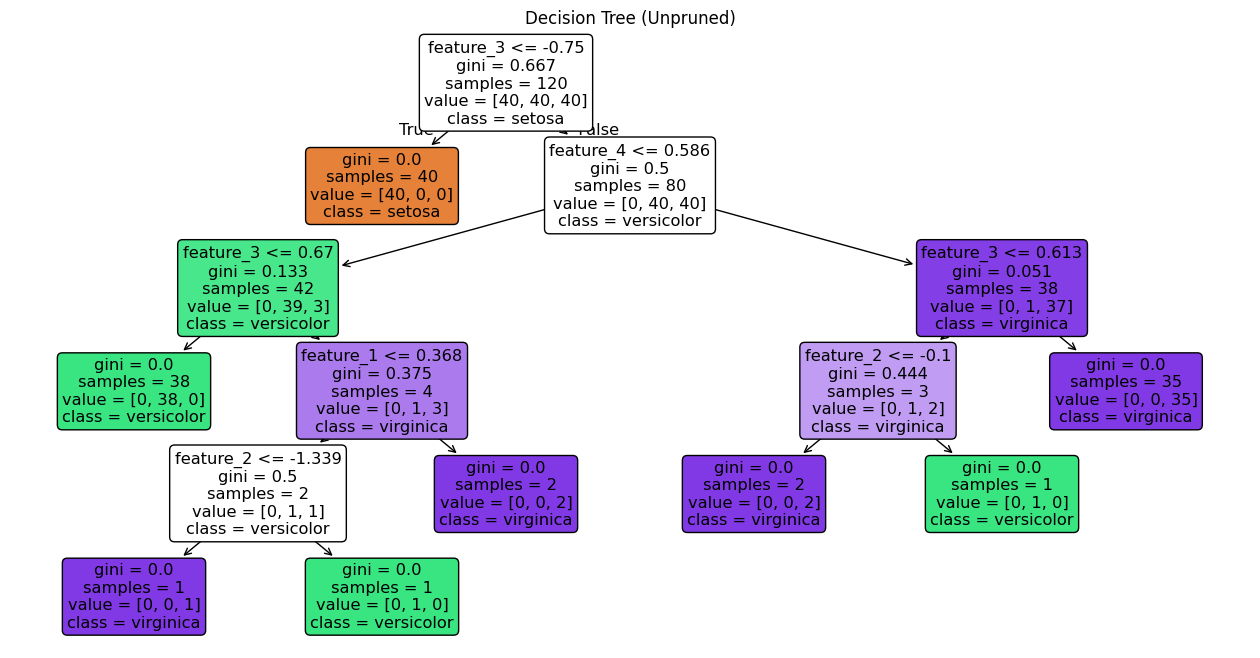

Decision Tree (Pruned)
Accuracy : 0.9333
F1-score : 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



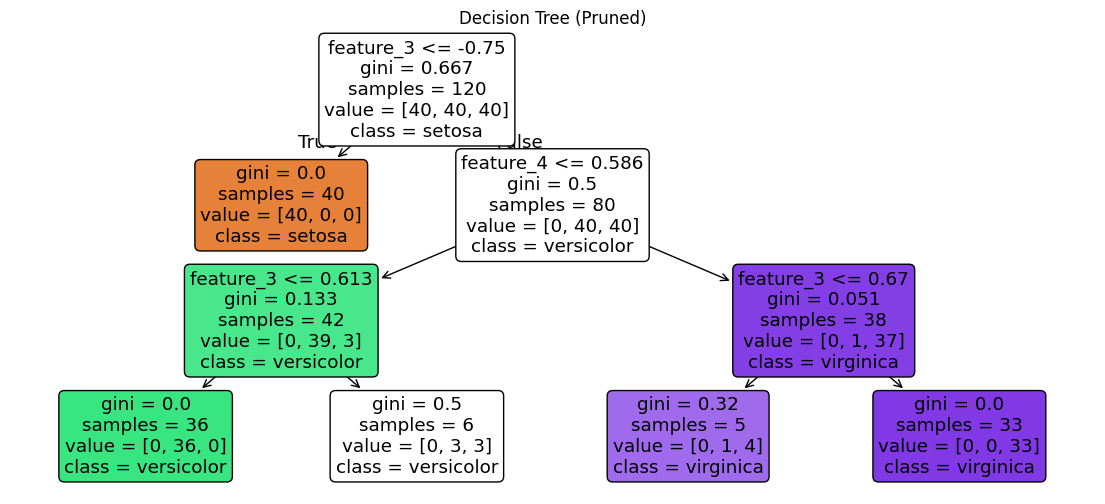

In [18]:
# =====================================================
# TASK 2: DECISION TREE CLASSIFICATION
# DATASET: IRIS
# =====================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Train a FULL Decision Tree
# -----------------------------
dt_full = DecisionTreeClassifier(
    random_state=42
)

dt_full.fit(X_train_iris, y_train_iris)

# Predictions
y_pred_full = dt_full.predict(X_test_iris)

# Evaluation
acc_full = accuracy_score(y_test_iris, y_pred_full)
f1_full  = f1_score(y_test_iris, y_pred_full, average="weighted")

print("Decision Tree (Unpruned)")
print("=" * 60)
print(f"Accuracy : {acc_full:.4f}")
print(f"F1-score : {f1_full:.4f}")
print("=" * 60)
print(classification_report(y_test_iris, y_pred_full))

# -----------------------------
# 2️⃣ Visualize FULL Tree
# -----------------------------
plt.figure(figsize=(16, 8))
plot_tree(
    dt_full,
    filled=True,
    feature_names=[f"feature_{i+1}" for i in range(X_train_iris.shape[1])],
    class_names=dt_full.classes_.astype(str),
    rounded=True
)
plt.title("Decision Tree (Unpruned)")
plt.show()


# -----------------------------
# 3️⃣ PRUNED Decision Tree
# -----------------------------
dt_pruned = DecisionTreeClassifier(
    max_depth=3,          # pruning
    min_samples_leaf=5,   # pruning
    random_state=42
)

dt_pruned.fit(X_train_iris, y_train_iris)

# Predictions
y_pred_pruned = dt_pruned.predict(X_test_iris)

# Evaluation
acc_pruned = accuracy_score(y_test_iris, y_pred_pruned)
f1_pruned  = f1_score(y_test_iris, y_pred_pruned, average="weighted")

print("Decision Tree (Pruned)")
print("=" * 60)
print(f"Accuracy : {acc_pruned:.4f}")
print(f"F1-score : {f1_pruned:.4f}")
print("=" * 60)
print(classification_report(y_test_iris, y_pred_pruned))

# -----------------------------
# 4️⃣ Visualize PRUNED Tree
# -----------------------------
plt.figure(figsize=(14, 6))
plot_tree(
    dt_pruned,
    filled=True,
    feature_names=[f"feature_{i+1}" for i in range(X_train_iris.shape[1])],
    class_names=dt_pruned.classes_.astype(str),
    rounded=True
)
plt.title("Decision Tree (Pruned)")
plt.show()


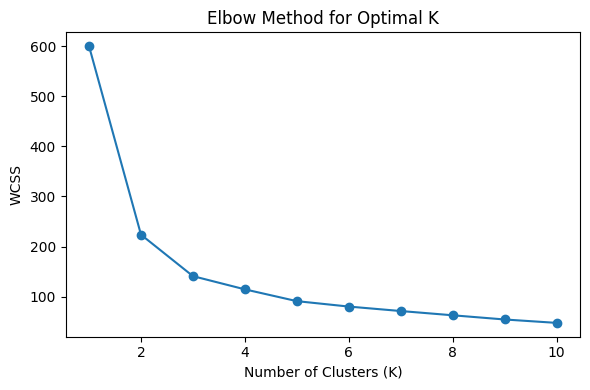

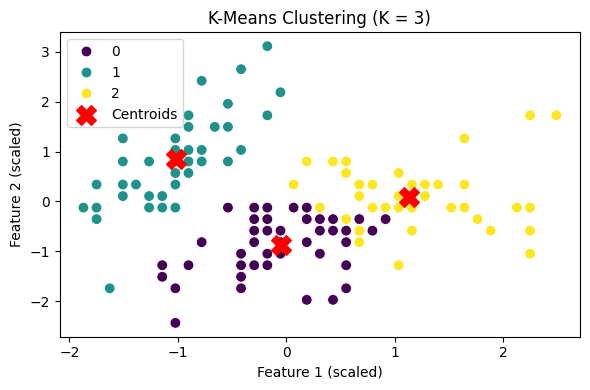

Cluster Distribution:
Cluster 0: 53 samples
Cluster 1: 50 samples
Cluster 2: 47 samples


In [19]:
# =====================================================
# TASK 3: K-MEANS CLUSTERING
# DATASET: IRIS (UNSUPERVISED)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1️⃣ Prepare Data (NO labels)
# -----------------------------
X_iris_full = np.vstack([X_train_iris, X_test_iris])

# Scaling (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris_full)

# -----------------------------
# 2️⃣ Elbow Method
# -----------------------------
wcss = []  # within-cluster sum of squares
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.tight_layout()
plt.show()

# -----------------------------
# 3️⃣ Apply K-Means (K = 3)
# -----------------------------
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

# -----------------------------
# 4️⃣ 2D Visualization
# (using first two features)
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters,
    palette="viridis",
    s=60
)

plt.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    s=200,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering (K = 3)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Cluster Sizes
# -----------------------------
unique, counts = np.unique(clusters, return_counts=True)
print("Cluster Distribution:")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples")


Best Hyperparameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
------------------------------------------------------------
Cross-Validation F1 Scores: [0.78787879 0.688      0.80291971 0.765625   0.74193548]
Mean CV F1 Score: 0.7573
------------------------------------------------------------
Random Forest – Churn Prediction
Accuracy : 0.9475
Precision: 0.9688
Recall   : 0.6526
F1-score : 0.7799
Classification Report:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       572
        True       0.97      0.65      0.78        95

    accuracy                           0.95       667
   macro avg       0.96      0.82      0.88       667
weighted avg       0.95      0.95      0.94       667

Top 10 Important Features:
Feature 6: Importance = 0.1226
Feature 4: Importance = 0.1127
Feature 16: Importance = 0.1032
Feature 7: Importance = 0.0548
Feature 9: Importance = 0.0514
Feature 14: Importance

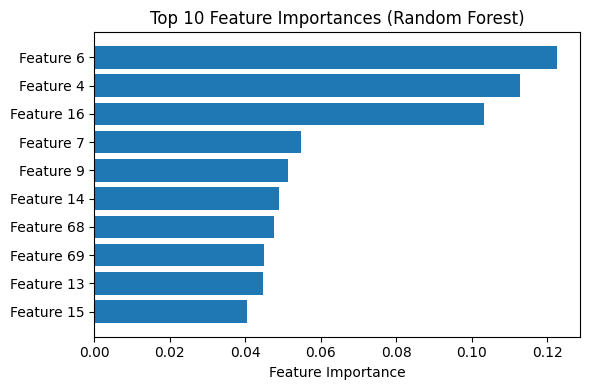

In [20]:
# =====================================================
# TASK: RANDOM FOREST CLASSIFIER
# DATASET: CHURN
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# -----------------------------
# 1️⃣ Base Random Forest Model
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 2️⃣ Hyperparameter Tuning
# -----------------------------
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_churn, y_train)

best_rf = grid_search.best_estimator_

print("Best Hyperparameters:")
print(grid_search.best_params_)
print("-" * 60)

# -----------------------------
# 3️⃣ Cross-Validation Score
# -----------------------------
cv_scores = cross_val_score(
    best_rf,
    X_train_churn,
    y_train,
    cv=5,
    scoring="f1"
)

print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f}")
print("-" * 60)

# -----------------------------
# 4️⃣ Train Final Model
# -----------------------------
best_rf.fit(X_train_churn, y_train)

# -----------------------------
# 5️⃣ Predictions
# -----------------------------
y_pred = best_rf.predict(X_test_churn)

# -----------------------------
# 6️⃣ Evaluation Metrics
# -----------------------------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Random Forest – Churn Prediction")
print("=" * 60)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("=" * 60)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣ Feature Importance Analysis
# -----------------------------
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:][::-1]

print("Top 10 Important Features:")
for idx in indices:
    print(f"Feature {idx+1}: Importance = {importances[idx]:.4f}")

# -----------------------------
# 8️⃣ Feature Importance Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.barh(
    [f"Feature {i+1}" for i in indices[::-1]],
    importances[indices[::-1]]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


C:\anaconda3\envs\idnet\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



SVM KERNEL COMPARISON — SENTIMENT DATASET
   Kernel  Accuracy  Precision    Recall       AUC
0  Linear  0.424242   0.311538  0.345238  0.752861
1     RBF  0.424242   0.417033  0.345238  0.779588


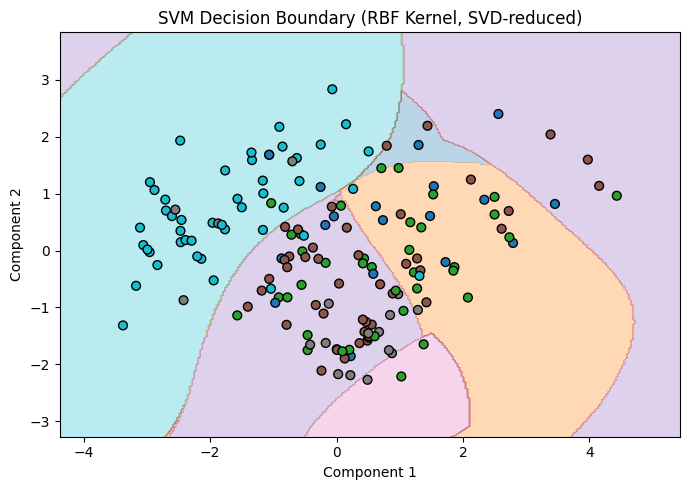

In [24]:
# =====================================================
# TASK: SUPPORT VECTOR MACHINE (SVM) FOR CLASSIFICATION
# DATASET: SENTIMENT
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.decomposition import TruncatedSVD

# -----------------------------------------------------
# 1️⃣ LABEL ENCODING (required for SVM + AUC)
# -----------------------------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_sent)
y_test_enc  = le.transform(y_test_sent)

results = []

# -----------------------------------------------------
# 2️⃣ SVM — LINEAR KERNEL
# -----------------------------------------------------
svm_linear = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_linear.fit(X_train_sent, y_train_enc)

y_pred_lin = svm_linear.predict(X_test_sent)
y_prob_lin = svm_linear.predict_proba(X_test_sent)

results.append({
    "Kernel": "Linear",
    "Accuracy": accuracy_score(y_test_enc, y_pred_lin),
    "Precision": precision_score(y_test_enc, y_pred_lin, average="macro"),
    "Recall": recall_score(y_test_enc, y_pred_lin, average="macro"),
    "AUC": roc_auc_score(y_test_enc, y_prob_lin, multi_class="ovr")
})

# -----------------------------------------------------
# 3️⃣ SVM — RBF KERNEL
# -----------------------------------------------------
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train_sent, y_train_enc)

y_pred_rbf = svm_rbf.predict(X_test_sent)
y_prob_rbf = svm_rbf.predict_proba(X_test_sent)

results.append({
    "Kernel": "RBF",
    "Accuracy": accuracy_score(y_test_enc, y_pred_rbf),
    "Precision": precision_score(y_test_enc, y_pred_rbf, average="macro"),
    "Recall": recall_score(y_test_enc, y_pred_rbf, average="macro"),
    "AUC": roc_auc_score(y_test_enc, y_prob_rbf, multi_class="ovr")
})

# -----------------------------------------------------
# 4️⃣ PRINT EVALUATION RESULTS (COMPARISON)
# -----------------------------------------------------
results_df = pd.DataFrame(results)

print("\nSVM KERNEL COMPARISON — SENTIMENT DATASET")
print("=" * 60)
print(results_df)
print("=" * 60)

# -----------------------------------------------------
# 5️⃣ DECISION BOUNDARY VISUALIZATION (SVD → 2D)
# -----------------------------------------------------
# NOTE: TruncatedSVD is used because data is sparse

X_full = np.vstack([
    X_train_sent.toarray(),
    X_test_sent.toarray()
])
y_full = np.hstack([y_train_enc, y_test_enc])

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_full)

svm_vis = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_vis.fit(X_2d, y_full)

# Mesh grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="tab10")
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_full,
    cmap="tab10",
    edgecolor="k",
    s=40
)
plt.title("SVM Decision Boundary (RBF Kernel, SVD-reduced)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()



Neural Network (MLPClassifier) – Sentiment Classification
Test Accuracy: 0.5152


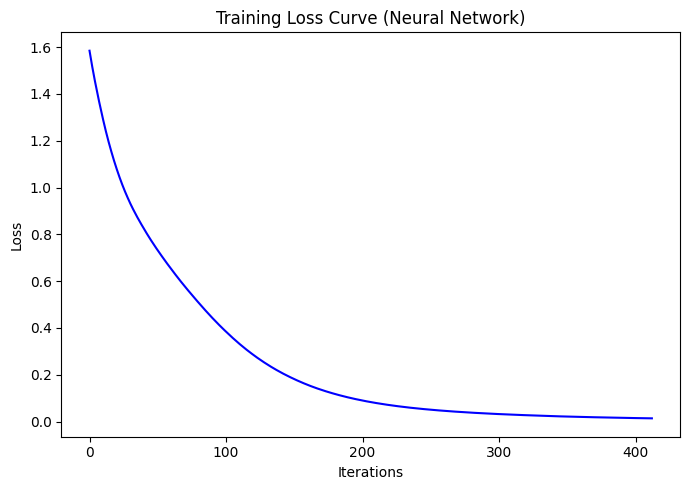

In [29]:
# =====================================================
# TASK 3: NEURAL NETWORKS USING SCIKIT-LEARN (MLP)
# DATASET: SENTIMENT
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning

# -----------------------------------------------------
# 0️⃣ WARNING HANDLING (CLEAN OUTPUT)
# -----------------------------------------------------
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# -----------------------------------------------------
# 1️⃣ PREPROCESSING
# -----------------------------------------------------

# Convert sparse matrices to dense (MLP requires dense input)
X_train_nn = X_train_sent.toarray()
X_test_nn  = X_test_sent.toarray()

# Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_sent)
y_test_enc  = le.transform(y_test_sent)

# -----------------------------------------------------
# 2️⃣ NEURAL NETWORK ARCHITECTURE
# -----------------------------------------------------
# Input layer  : number of features
# Hidden layers: 128, 64 neurons
# Output layer : sentiment classes
# Optimizer    : Adam (Backpropagation)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,          # increased for better convergence
    learning_rate_init=0.001,
    random_state=42
)

# -----------------------------------------------------
# 3️⃣ MODEL TRAINING
# -----------------------------------------------------

mlp.fit(X_train_nn, y_train_enc)

# -----------------------------------------------------
# 4️⃣ MODEL EVALUATION
# -----------------------------------------------------

y_pred = mlp.predict(X_test_nn)
accuracy = accuracy_score(y_test_enc, y_pred)

print("\nNeural Network (MLPClassifier) – Sentiment Classification")
print("=" * 65)
print(f"Test Accuracy: {accuracy:.4f}")
print("=" * 65)

# -----------------------------------------------------
# 5️⃣ TRAINING LOSS VISUALIZATION
# -----------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, color="blue")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Neural Network)")
plt.tight_layout()
plt.show()
